In [168]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.formula.api as smf
from sklearn.inspection import permutation_importance
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import os

Doing basic setup

In [169]:
path = r'/content/final_modelling_ready_dataset.csv'
df = pd.read_csv(path)

df['intl_experience'] = (df["year"] - df["debut_year"]).clip(lower=0).fillna(0)

role_map = {"Bowling Allrounder":"Allrounder",
            "Batting Allrounder":"Allrounder",
            "Allrounder":"Allrounder",
            "Bowler":"Bowler",
            "Top order Batter":"Batsman",
            "Middle order Batter":"Batsman",
            "Opening Batter":"Batsman",
            "Batter":"Batsman",
            "Wicketkeeper Batter":"Wicketkeeper",
            "Wicketkeeper":"Wicketkeeper"}
df["mapped_player_role"] = df["player_role"].map(role_map)



sold = df[(df["auction_result"]=="sold") & df["sold_price"].notna() & (df['sold_price']>0)].copy()

sold["log_price"] = np.log(sold["sold_price"])
sold["is_capped"] = sold["is_capped"].astype(int)


sold["new_base_price_in_cr"] = sold["base_price"]/1e7

sold["new_overseas"] = pd.to_numeric(sold["new_overseas"].map({
    True:1,
    False:0,
    "True":1,
    "False":0
}),errors="coerce")


print("Sold players with price ", len(sold))


Sold players with price  1644


Some basic checking of duplicates where i just becoming bit sure about duplicates

In [170]:
print("is bbm identical to bbi???")
for a,b in [("bbm_wkts", "bbi_wkts"), ("bbm_runs", "bbi_runs")]:
  checkin_both = df[[a,b]].dropna()
  print(f"  {a} vs {b}: {(checkin_both[a] != checkin_both[b]).sum()} of {len(checkin_both)} differ")

print("just conforming that tournament is jsut a relabel of year")
print("\ntournament is a 1:1 relabel of year (max distinct per year):",
      df.dropna(subset=["tournament"]).groupby("year")["tournament"].nunique().max())


print("\nstatus vs auction_result:")
print(pd.crosstab(df["auction_result"].fillna("NA"), df["status"].fillna("NA")))
print("\ntransferred vs auction_result:")
print(pd.crosstab(df["auction_result"].fillna("NA"), df["transferred"].fillna("NA")))

is bbm identical to bbi???
  bbm_wkts vs bbi_wkts: 0 of 1077 differ
  bbm_runs vs bbi_runs: 0 of 1077 differ
just conforming that tournament is jsut a relabel of year

tournament is a 1:1 relabel of year (max distinct per year): 1

status vs auction_result:
status            NA   New  RTM  Retained
auction_result                           
NA                 8    24    0         0
retained           0     0    0      1108
sold             289  1316   39         0
transferred        6    27    0        13
unsold          1198     0    0         0

transferred vs auction_result:
transferred      0.0  1.0    NA
auction_result                 
NA                24    0     8
retained        1105    0     3
sold            1355    0   289
transferred        0   46     0
unsold             0    0  1198


checking multicollinearity and then relevance with the target variable.

In [171]:
numeric_cols = ["base_price","new_base_price_in_cr","age_during_auction","intl_experience","matches","innings","no","runs","highestscore","batting_average","balls_faced","batting_strikerate","100s","50s","4s","6s""Ct","wickets","economy","balls","bowl_ave","bowl_strikerate","4w","5w","bbi_runs", "bbi_wkts","purse_spent_in_cr","purse_left_in_cr","purse_spent","purse_left"]


corelation_check = sold[numeric_cols].corr()


for i in range(len(numeric_cols)):
  for j in range(i+1,len(numeric_cols)):
    if corelation_check.iloc[i,j] > 0.8:
      print(f"{numeric_cols[i]} <--> {numeric_cols[j]} r = {round(corelation_check.iloc[i,j],3)}")

base_price <--> new_base_price_in_cr r = 1.0
innings <--> runs r = 0.896
innings <--> balls_faced r = 0.901
innings <--> 4s r = 0.84
runs <--> highestscore r = 0.88
runs <--> balls_faced r = 0.986
runs <--> 50s r = 0.852
runs <--> 4s r = 0.962
runs <--> 6s r = 0.866
highestscore <--> balls_faced r = 0.86
highestscore <--> 4s r = 0.836
balls_faced <--> 50s r = 0.828
balls_faced <--> 4s r = 0.955
balls_faced <--> 6s r = 0.801
50s <--> 4s r = 0.834
wickets <--> balls r = 0.909
bowl_ave <--> bowl_strikerate r = 0.939
purse_spent_in_cr <--> purse_spent r = 1.0
purse_left_in_cr <--> purse_left r = 1.0


In [172]:


for c in numeric_cols:
    d = sold[[c, "log_price"]].dropna()
    print(f"{c:16s} n={len(d):4d} r={d[c].corr(d['log_price']):+.3f}")

base_price       n=1240 r=+0.670
new_base_price_in_cr n=1240 r=+0.670
age_during_auction n=1480 r=+0.224
intl_experience  n=1644 r=+0.454
matches          n= 694 r=+0.527
innings          n= 617 r=+0.404
no               n= 617 r=+0.238
runs             n= 617 r=+0.365
highestscore     n= 617 r=+0.315
batting_average  n= 552 r=+0.230
balls_faced      n= 617 r=+0.342
batting_strikerate n= 611 r=+0.160
100s             n= 617 r=+0.155
50s              n= 617 r=+0.290
4s               n= 617 r=+0.307
6s               n= 617 r=+0.396
Ct               n= 694 r=+0.409
wickets          n= 475 r=+0.375
economy          n= 475 r=-0.093
balls            n= 475 r=+0.411
bowl_ave         n= 407 r=-0.021
bowl_strikerate  n= 407 r=-0.011
4w               n= 475 r=+0.140
5w               n= 475 r=+0.089
bbi_runs         n= 407 r=-0.047
bbi_wkts         n= 407 r=+0.279
purse_spent_in_cr n=1191 r=+0.151
purse_left_in_cr n=1191 r=-0.097
purse_spent      n=1191 r=+0.151
purse_left       n=1191 r=-0.097


In [173]:

categorical_cols = ["year","mapped_player_role","is_capped","new_overseas","has_prior_season","is_mega_auction","bowling_style","nationality","batting_style", "prior_season_year"]
for col in categorical_cols:
    d = sold.dropna(subset=[col, "log_price"]).copy(); d[col] = d[col].astype(str)

    groups = [g["log_price"].values for _, g in d.groupby(col)]
    if len(groups) < 2:
      continue

    F, p = stats.f_oneway(*groups)

    grand = d["log_price"].mean()
    sst = ((d["log_price"]-grand)**2).sum()
    ssb = 0.0

    for g in groups:
      ssb += len(g)*(g.mean()-grand)**2
    print(f"{col} n={len(d)} groups={d[col].nunique():3d} F={F:8.2f} p={p:.1e} eta2={ssb/sst:.4f}")

year n=1644 groups= 19 F=    6.75 p=1.1e-16 eta2=0.0696
mapped_player_role n=1471 groups=  4 F=    3.58 p=1.3e-02 eta2=0.0073
is_capped n=1644 groups=  2 F=  906.97 p=5.2e-159 eta2=0.3558
new_overseas n=1615 groups=  2 F=  124.45 p=6.8e-28 eta2=0.0716
has_prior_season n=1644 groups=  2 F=  328.05 p=5.5e-67 eta2=0.1665
is_mega_auction n=1644 groups=  2 F=   43.22 p=6.6e-11 eta2=0.0256
bowling_style n=1365 groups= 21 F=    3.70 p=7.1e-08 eta2=0.0522
nationality n=1480 groups= 19 F=    6.36 p=2.2e-15 eta2=0.0726
batting_style n=1480 groups=  2 F=    1.24 p=2.7e-01 eta2=0.0008
prior_season_year n=1644 groups= 19 F=    6.75 p=1.1e-16 eta2=0.0696


In [174]:

print('Checking VIF of selected numeric cols')
selected_numeric_cols = ["new_base_price_in_cr","age_during_auction","intl_experience",
                         "matches","no","runs","batting_average",
              "batting_strikerate","100s",
                "Ct","wickets","economy","bowl_ave","4w","5w","bbi_runs",
                "bbi_wkts"]
X = sold[selected_numeric_cols].dropna()
Xc = add_constant(X)
scores = []
for i in range(Xc.shape[1]):
  scores.append(variance_inflation_factor(Xc.values, i))
value = pd.Series(scores, index=Xc.columns).drop("const").sort_values(ascending=False)

print(round(value,2))

print('Correlation of selected columns with target variable')
for c in selected_numeric_cols:
    d = sold[[c, "log_price"]].dropna()
    print(f"  {c:16s} n={len(d):4d}  r={d[c].corr(d['log_price']):+.3f}")

Checking VIF of selected numeric cols
wickets                 5.05
matches                 4.95
bbi_wkts                4.31
runs                    3.53
batting_average         2.94
intl_experience         2.59
bowl_ave                2.20
age_during_auction      2.01
no                      1.94
bbi_runs                1.90
new_base_price_in_cr    1.83
4w                      1.82
batting_strikerate      1.61
economy                 1.60
Ct                      1.59
100s                    1.54
5w                      1.28
dtype: float64
Correlation of selected columns with target variable
  new_base_price_in_cr n=1240  r=+0.670
  age_during_auction n=1480  r=+0.224
  intl_experience  n=1644  r=+0.454
  matches          n= 694  r=+0.527
  no               n= 617  r=+0.238
  runs             n= 617  r=+0.365
  batting_average  n= 552  r=+0.230
  batting_strikerate n= 611  r=+0.160
  100s             n= 617  r=+0.155
  Ct               n= 694  r=+0.409
  wickets          n= 475  r=+0.3

In [175]:
print('Checking VIF of selected numeric cols2')
selected_numeric_cols2 = ["new_base_price_in_cr","age_during_auction","intl_experience","matches","no","runs","batting_average","batting_strikerate","100s","Ct","wickets","economy","bowl_ave","bbi_wkts","bbi_runs","4w"]



X2 = sold[selected_numeric_cols2].dropna()
Xc2 = add_constant(X2)
scores2 = []
for i in range(Xc2.shape[1]):
  scores2.append(variance_inflation_factor(Xc2.values, i))
value2 = pd.Series(scores2, index=Xc2.columns).drop("const").sort_values(ascending=False)

print(round(value2,2))


print('Correlation of selected columns2 with target variable')
for c in selected_numeric_cols2:
    d = sold[[c, "log_price"]].dropna()
    print(f"  {c:16s} n={len(d):4d}  r={d[c].corr(d['log_price']):+.3f}")

Checking VIF of selected numeric cols2
wickets                 4.77
matches                 4.65
bbi_wkts                4.16
runs                    3.44
batting_average         2.94
intl_experience         2.51
bowl_ave                2.15
age_during_auction      1.97
no                      1.94
bbi_runs                1.88
new_base_price_in_cr    1.82
4w                      1.80
batting_strikerate      1.61
economy                 1.59
Ct                      1.59
100s                    1.54
dtype: float64
Correlation of selected columns2 with target variable
  new_base_price_in_cr n=1240  r=+0.670
  age_during_auction n=1480  r=+0.224
  intl_experience  n=1644  r=+0.454
  matches          n= 694  r=+0.527
  no               n= 617  r=+0.238
  runs             n= 617  r=+0.365
  batting_average  n= 552  r=+0.230
  batting_strikerate n= 611  r=+0.160
  100s             n= 617  r=+0.155
  Ct               n= 694  r=+0.409
  wickets          n= 475  r=+0.375
  economy          n= 47

Now implementing ML modeling
where I will consider RMSE, MAE and R^2 as my checking parameter

In [176]:
numeric_cols = ["new_base_price_in_cr", "age_during_auction", "intl_experience"]
categorical_cols = ["mapped_player_role", "is_capped", "new_overseas","has_prior_season"]


tree_stat_cols = ["matches","no","runs","batting_average","batting_strikerate","100s", "Ct","wickets","economy","bowl_ave","bbi_wkts","bbi_runs","4w"]

core_modelling_cols = numeric_cols + categorical_cols
new_data = sold.dropna(subset=core_modelling_cols).copy().reset_index(drop=True)

print("Rows that gonna use for modelling is" ,len(new_data))
y = new_data['log_price']
year_d = pd.get_dummies(new_data['year'], prefix='yr',dtype=float)
bowl_d = pd.get_dummies(new_data['bowling_style'], prefix='bowl',dtype=float)
role_d = pd.get_dummies(new_data['mapped_player_role'], prefix='role',dtype=float)

num = new_data[numeric_cols].reset_index(drop=True)
flags = new_data[['is_capped','new_overseas','has_prior_season']].reset_index(drop=True)

tree_data = new_data[tree_stat_cols].reset_index(drop=True)



Rows that gonna use for modelling is 1104


In [177]:

tr,te = train_test_split(np.arange(len(new_data)),test_size = 0.2,random_state=42)
train_data  = new_data.iloc[tr]
test_data = new_data.iloc[te]

print("train data rows",len(train_data))
print("test data rows",len(test_data))


train data rows 883
test data rows 221


In [178]:


def test_scores(y_true, y_pred):
    print(" TEST: R2 =", round(r2_score(y_true, y_pred), 3),
          "| RMSE =", round(np.sqrt(mean_squared_error(y_true, y_pred)), 3),
          "| MAE =", round(mean_absolute_error(y_true, y_pred), 3))

Below All models checked on Random Splitting

In [179]:
print("MODEL 0 - Mean only:")
mean_pred = np.full(len(test_data), train_data["log_price"].mean())
test_scores(test_data["log_price"], mean_pred)

MODEL 0 - Mean only:
 TEST: R2 = -0.003 | RMSE = 1.33 | MAE = 1.145


In [180]:
print("MODEL 1 - Season baseline:  log_price ~ year")
m1 = smf.ols("log_price ~ C(year)", data=train_data).fit()
print(m1.summary())
test_scores(test_data["log_price"], m1.predict(test_data))

MODEL 1 - Season baseline:  log_price ~ year
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     3.227
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           5.22e-05
Time:                        19:36:06   Log-Likelihood:                -1478.7
No. Observations:                 883   AIC:                             2987.
Df Residuals:                     868   BIC:                             3059.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [181]:
print("MODEL 2 - Base price + season:  log_price ~ year + new_base_price_in_cr")
print(len(train_data))
m2 = smf.ols("log_price ~ C(year) + new_base_price_in_cr", data=train_data).fit()
print(m2.summary())
test_scores(test_data["log_price"], m2.predict(test_data))

MODEL 2 - Base price + season:  log_price ~ year + new_base_price_in_cr
883
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     43.87
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.62e-95
Time:                        19:36:06   Log-Likelihood:                -1251.7
No. Observations:                 883   AIC:                             2535.
Df Residuals:                     867   BIC:                             2612.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

In [182]:
hedonic = ("log_price ~ C(year) + new_base_price_in_cr + age_during_auction + intl_experience + C(mapped_player_role) + is_capped + new_overseas")

print("MODEL 3 - Hedonic:", hedonic)
m_full = smf.ols(hedonic, data=train_data).fit()
bp = het_breuschpagan(m_full.resid, m_full.model.exog)
print("Breusch-Pagan p-value:", bp[1])

MODEL 3 - Hedonic: log_price ~ C(year) + new_base_price_in_cr + age_during_auction + intl_experience + C(mapped_player_role) + is_capped + new_overseas
Breusch-Pagan p-value: 1.3479563670329928e-10


In [183]:
# (A) PREDICTION — fit on train, score on test (no HC3)
m3 = smf.ols(hedonic, data=train_data).fit()
test_scores(test_data["log_price"], m3.predict(test_data))
print(m3.summary())

# (B) COEFFICIENTS — fit on all data with HC3, for the reported table
m3_coef = smf.ols(hedonic, data=new_data).fit(cov_type="HC3")
print(m3_coef.summary())

 TEST: R2 = 0.435 | RMSE = 0.998 | MAE = 0.813
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.499
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     38.91
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          6.41e-113
Time:                        19:36:07   Log-Likelihood:                -1196.1
No. Observations:                 883   AIC:                             2438.
Df Residuals:                     860   BIC:                             2548.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

In [184]:
print("MODEL 4 - Random forest:")
X_rf = pd.concat([year_d,role_d, flags, num, tree_data], axis=1)

rf2 = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_rf.iloc[tr], y[tr])
test_scores(y[te], rf2.predict(X_rf.iloc[te]))
rf_pred_train = rf2.predict(X_rf.iloc[tr])

print("RF train R2:", round(r2_score(y[tr], rf_pred_train), 3))
importance2 = pd.Series(rf2.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
print(importance2.round(4))


MODEL 4 - Random forest:
 TEST: R2 = 0.509 | RMSE = 0.93 | MAE = 0.745
RF train R2: 0.912
new_base_price_in_cr    0.4935
age_during_auction      0.1052
matches                 0.0520
intl_experience         0.0290
Ct                      0.0247
runs                    0.0228
is_capped               0.0176
batting_average         0.0175
batting_strikerate      0.0156
role_Wicketkeeper       0.0153
role_Bowler             0.0149
role_Batsman            0.0146
role_Allrounder         0.0141
bowl_ave                0.0134
yr_2024                 0.0134
economy                 0.0133
new_overseas            0.0104
bbi_runs                0.0101
yr_2022                 0.0098
yr_2018                 0.0091
yr_2021                 0.0089
yr_2026                 0.0083
yr_2017                 0.0083
wickets                 0.0079
yr_2020                 0.0071
yr_2016                 0.0066
no                      0.0065
yr_2025                 0.0060
has_prior_season        0.0056
yr_2023    

##Now Models on Temporal Heldout

In [185]:
train_t  = new_data[new_data['year']<=2022]
test_t = new_data[new_data['year']>=2023]

print("train data rows",len(train_t))
print("test data rows",len(test_t))

train data rows 750
test data rows 354


In [186]:

print("Mean-only (temporal):")
mean_pred_t = np.full(len(test_t), train_t["log_price"].mean())
test_scores(test_t["log_price"], mean_pred_t)


Mean-only (temporal):
 TEST: R2 = -0.016 | RMSE = 1.374 | MAE = 1.18


In [187]:
print("Season (temporal):")
m1_t = smf.ols("log_price ~ year", data=train_t).fit()
test_scores(test_t["log_price"], m1_t.predict(test_t))

Season (temporal):
 TEST: R2 = -0.024 | RMSE = 1.38 | MAE = 1.183


In [188]:
print("Base + season (temporal):")
m2_t = smf.ols("log_price ~ year + new_base_price_in_cr", data=train_t).fit()
test_scores(test_t["log_price"], m2_t.predict(test_t))

Base + season (temporal):
 TEST: R2 = 0.491 | RMSE = 0.972 | MAE = 0.834


In [189]:
hedonic_trend = ("log_price ~ year + new_base_price_in_cr + age_during_auction + intl_experience + C(mapped_player_role) + is_capped + new_overseas + is_mega_auction")
m_temporal = smf.ols(hedonic_trend, data=train_t).fit()
print("Hedonic (temporal):")
test_scores(test_t["log_price"], m_temporal.predict(test_t))

Hedonic (temporal):
 TEST: R2 = 0.493 | RMSE = 0.971 | MAE = 0.803


In [190]:
rf_cols = X_rf.columns

X_train_t = X_rf.loc[train_t.index]
X_test_t  = X_rf.loc[test_t.index]

rf_t = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train_t, train_t["log_price"])

print("Random forest Model:")
test_scores(test_t["log_price"], rf_t.predict(X_test_t))
rf_t_pred_train = rf_t.predict(X_train_t)

print("train R2:", round(r2_score(train_t['log_price'], rf_t_pred_train), 3))


importance_t = pd.Series(rf2.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
print(importance_t.round(4))

Random forest Model:
 TEST: R2 = 0.516 | RMSE = 0.948 | MAE = 0.744
train R2: 0.9
new_base_price_in_cr    0.4935
age_during_auction      0.1052
matches                 0.0520
intl_experience         0.0290
Ct                      0.0247
runs                    0.0228
is_capped               0.0176
batting_average         0.0175
batting_strikerate      0.0156
role_Wicketkeeper       0.0153
role_Bowler             0.0149
role_Batsman            0.0146
role_Allrounder         0.0141
bowl_ave                0.0134
yr_2024                 0.0134
economy                 0.0133
new_overseas            0.0104
bbi_runs                0.0101
yr_2022                 0.0098
yr_2018                 0.0091
yr_2021                 0.0089
yr_2026                 0.0083
yr_2017                 0.0083
wickets                 0.0079
yr_2020                 0.0071
yr_2016                 0.0066
no                      0.0065
yr_2025                 0.0060
has_prior_season        0.0056
yr_2023            

## LOO

In [191]:
rows = []
lin_obs = []; lin_pred = []; lin_year = []
rf_obs = []; rf_pred = []; rf_year = []

for test_year in sorted(new_data["year"].unique()):
    train_y = new_data[new_data["year"] != test_year]
    test_y  = new_data[new_data["year"] == test_year]
    if len(test_y) < 5:
        continue


    p_null = np.full(len(test_y), train_y["log_price"].mean())

    m_season = smf.ols("log_price ~ year", data=train_y).fit()
    p_season = m_season.predict(test_y)


    m_base = smf.ols("log_price ~ year + new_base_price_in_cr", data=train_y).fit()
    p_base = m_base.predict(test_y)

    m = smf.ols(hedonic_trend, data=train_y).fit()
    p_lin = m.predict(test_y)


    rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(
        X_rf.loc[train_y.index], train_y["log_price"])
    p_rf = rf.predict(X_rf.loc[test_y.index])

    rows.append({
        "held_out_year": test_year, "n_test": len(test_y),
        "null_R2":   round(r2_score(test_y["log_price"], p_null), 3),
        "season_R2": round(r2_score(test_y["log_price"], p_season), 3),
        "base_R2":   round(r2_score(test_y["log_price"], p_base), 3),
        "lin_R2":    round(r2_score(test_y["log_price"], p_lin), 3),
        "rf_R2":     round(r2_score(test_y["log_price"], p_rf), 3),
    })

    lin_obs += list(test_y["log_price"]); lin_pred += list(p_lin); lin_year += list(test_y["year"])
    rf_obs  += list(test_y["log_price"]); rf_pred  += list(p_rf);  rf_year  += list(test_y["year"])

loo = pd.DataFrame(rows)
print(loo.to_string(index=False))

print("\nNull        — avg R2 =", round(loo["null_R2"].mean(), 3))
print("Season      — avg R2 =", round(loo["season_R2"].mean(), 3))
print("Base+season — avg R2 =", round(loo["base_R2"].mean(), 3))
print("Hedonic     — avg R2 =", round(loo["lin_R2"].mean(), 3))
print("Forest      — avg R2 =", round(loo["rf_R2"].mean(), 3))

 held_out_year  n_test  null_R2  season_R2  base_R2  lin_R2  rf_R2
          2008      72   -0.234     -1.584   -0.388   0.256 -0.170
          2009      16   -0.013     -0.071   -2.262  -1.081  0.358
          2010      11   -0.116     -0.063    0.320   0.266  0.218
          2012      23   -0.004     -0.027    0.149   0.324  0.440
          2016      79   -0.190     -0.177    0.321   0.458  0.467
          2017      57   -0.302     -0.284    0.291   0.406  0.457
          2018     151   -0.060     -0.075    0.351   0.411  0.494
          2019      54   -0.054     -0.050    0.300   0.419  0.390
          2020      55   -0.004     -0.004    0.392   0.398  0.319
          2021      50   -0.026     -0.029    0.353   0.432  0.432
          2022     182   -0.008     -0.005    0.428   0.474  0.579
          2023      67   -0.149     -0.183    0.465   0.590  0.601
          2024      61   -0.009     -0.004    0.327   0.265  0.322
          2025     168   -0.083     -0.083    0.575   0.565  0

In [192]:
def residual_plots(observed, predicted, years, title):
    observed  = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    years  = np.asarray(years)
    resid = observed - predicted

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].scatter(predicted, observed, s=10, alpha=0.4)
    lo, hi = observed.min(), observed.max()
    ax[0].plot([lo, hi], [lo, hi], "r--")
    ax[0].set_xlabel("Predicted log price"); ax[0].set_ylabel("Observed log price")
    ax[0].set_title(title + " — Predicted vs Observed")



    year_list = sorted(pd.unique(years))
    box = []
    for yv in year_list:
        box.append(resid[years == yv])
    ax[1].boxplot(box)
    ax[1].set_xticks(range(1, len(year_list) + 1))
    ax[1].set_xticklabels(year_list, rotation=45)
    ax[1].axhline(0, color="r", ls="--")
    ax[1].set_xlabel("Auction year"); ax[1].set_ylabel("Residual")
    ax[1].set_title(title + " — Residuals by year")
    plt.tight_layout(); plt.show()

In [193]:
OUTPUT_DIR = r"/content/images"

def save(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print("saved figure:", filename)

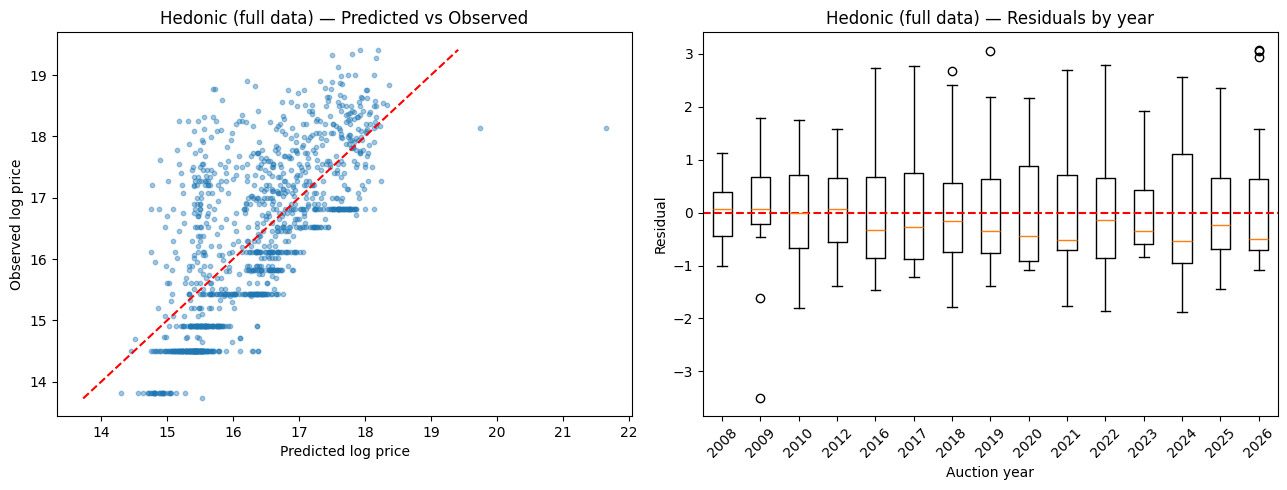

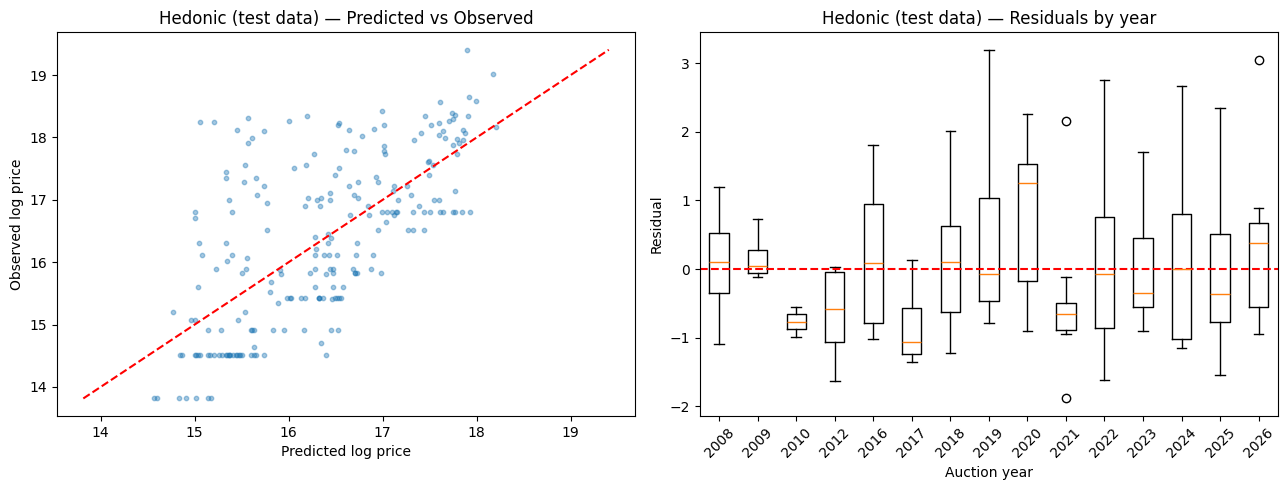

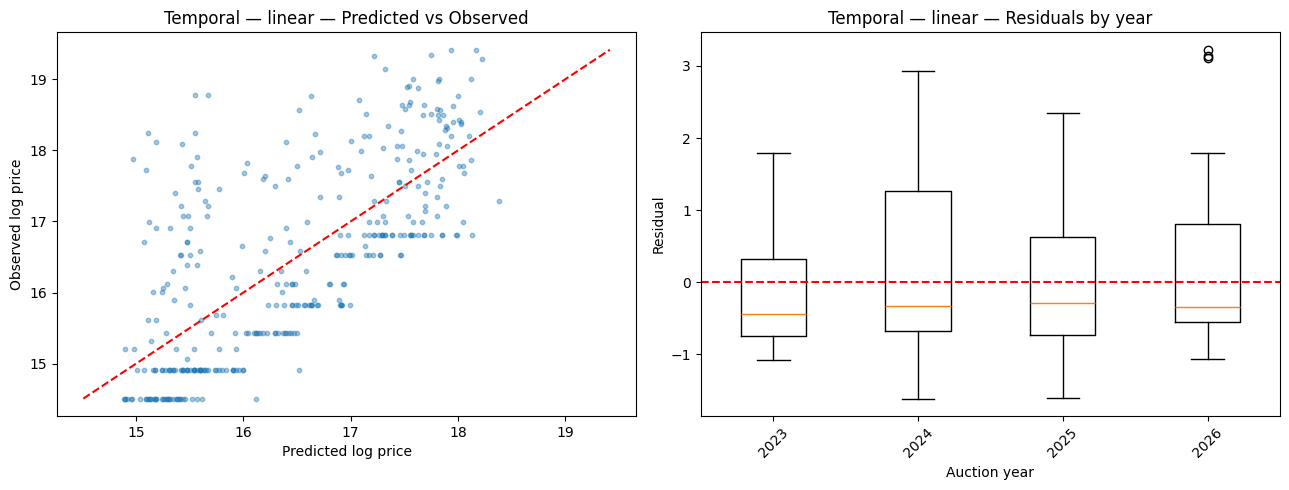

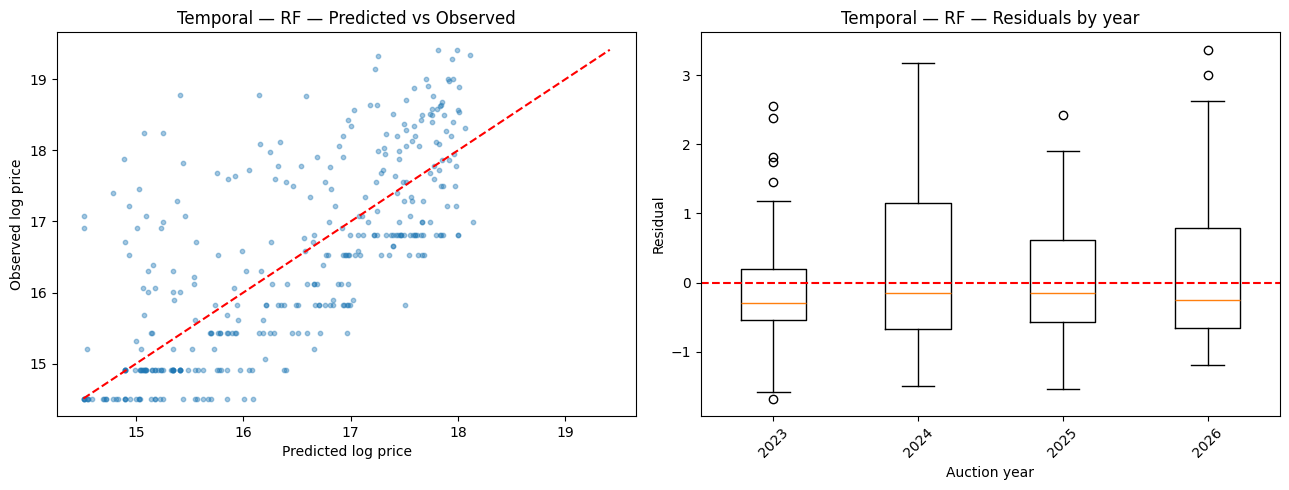

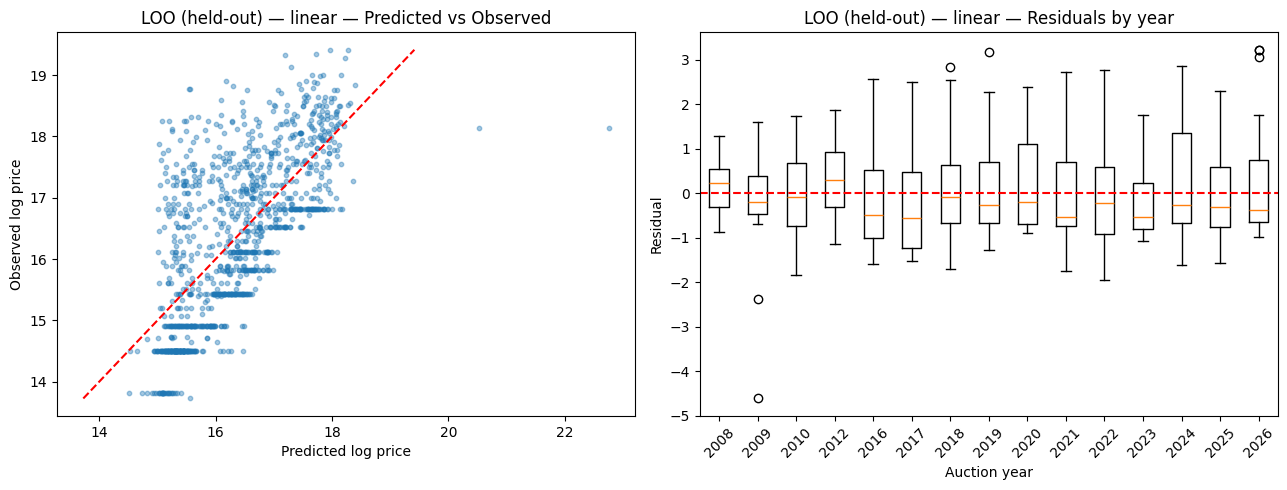

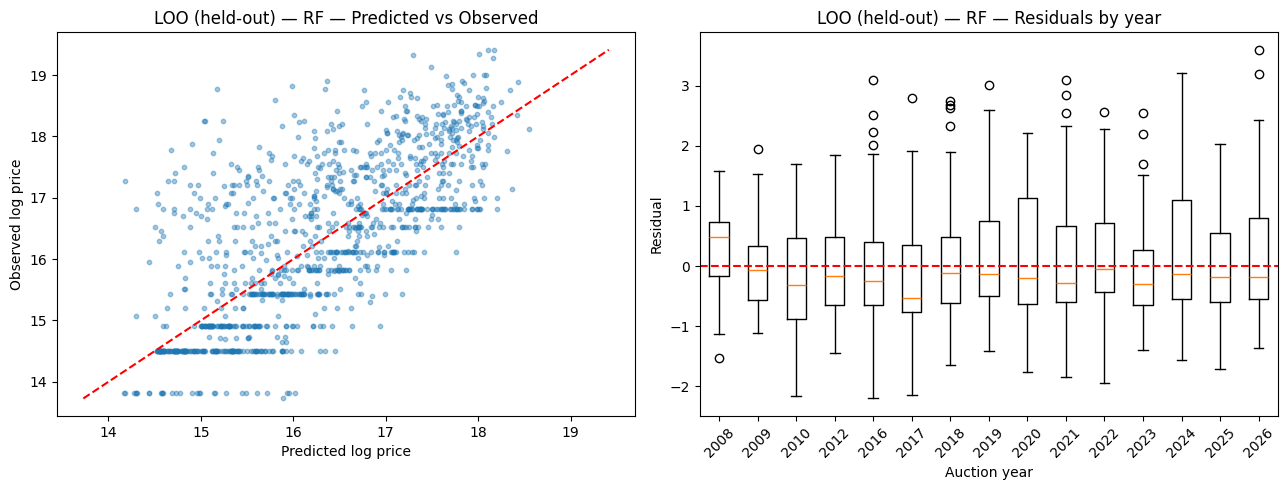

In [194]:
#Hedonic
residual_plots(new_data["log_price"], m3_coef.predict(new_data), new_data["year"], "Hedonic (full data)")
residual_plots(test_data["log_price"], m3.predict(test_data), test_data["year"], "Hedonic (test data)")


#Temporal holdout
residual_plots(test_t["log_price"], m_temporal.predict(test_t), test_t["year"], "Temporal — linear")
residual_plots(test_t["log_price"], rf_t.predict(X_test_t),      test_t["year"], "Temporal — RF")

#Leave-one-year-out — (includes Linear and RF both)
residual_plots(lin_obs, lin_pred, lin_year, "LOO (held-out) — linear")
residual_plots(rf_obs,  rf_pred,  rf_year,  "LOO (held-out) — RF")

In [195]:
import os, re

def save_plots(observed, predicted, years, title, savedir="thesis_plots"):
    os.makedirs(savedir, exist_ok=True)
    observed = np.asarray(observed, float); predicted = np.asarray(predicted, float); years = np.asarray(years)
    resid = observed - predicted
    slug = re.sub(r"[^a-z0-9]+", "_", title.lower()).strip("_")

    # (a) predicted vs observed -> its own file
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.scatter(predicted, observed, s=10, alpha=0.4)
    lo, hi = observed.min(), observed.max(); ax.plot([lo, hi], [lo, hi], "r--")
    ax.set_xlabel("Predicted log price"); ax.set_ylabel("Observed log price")
    ax.set_title(title + " — Predicted vs Observed")
    fig.savefig(f"{savedir}/{slug}__pred_vs_obs.png", dpi=200, bbox_inches="tight"); plt.show(); plt.close(fig)

    # (b) residuals by year -> its own file
    fig, ax = plt.subplots(figsize=(8, 5.5))
    yl = sorted(pd.unique(years))
    ax.boxplot([resid[years == yv] for yv in yl])
    ax.set_xticks(range(1, len(yl) + 1)); ax.set_xticklabels(yl, rotation=45)
    ax.axhline(0, color="r", ls="--"); ax.set_xlabel("Auction year"); ax.set_ylabel("Residual")
    ax.set_title(title + " — Residuals by year")
    fig.savefig(f"{savedir}/{slug}__resid_by_year.png", dpi=200, bbox_inches="tight"); plt.show(); plt.close(fig)
    print(f"saved {slug}__pred_vs_obs.png  and  {slug}__resid_by_year.png")

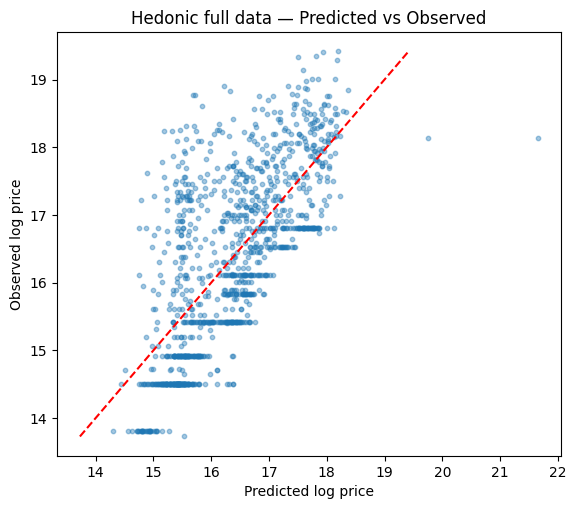

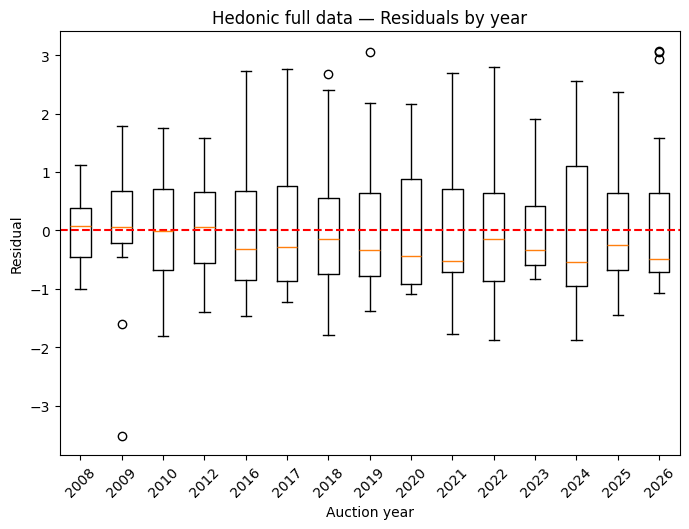

saved hedonic_full_data__pred_vs_obs.png  and  hedonic_full_data__resid_by_year.png


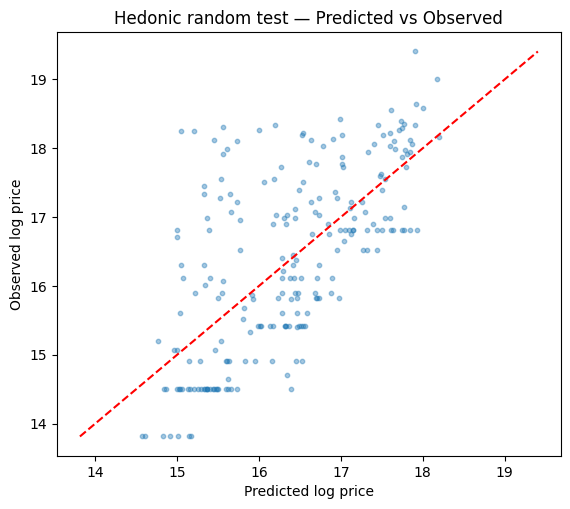

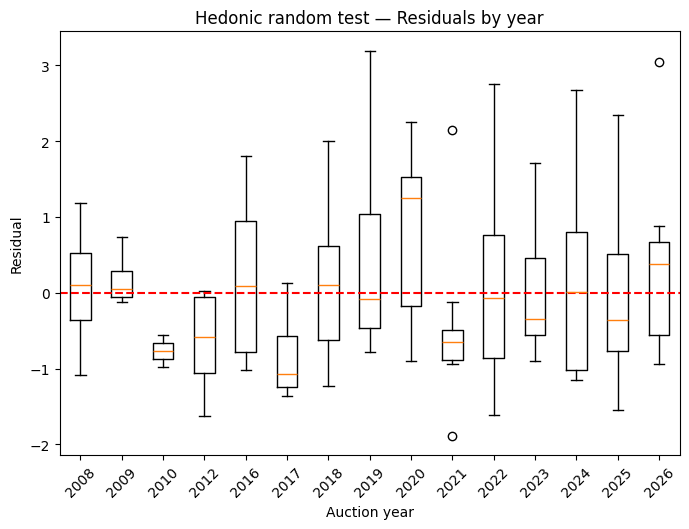

saved hedonic_random_test__pred_vs_obs.png  and  hedonic_random_test__resid_by_year.png


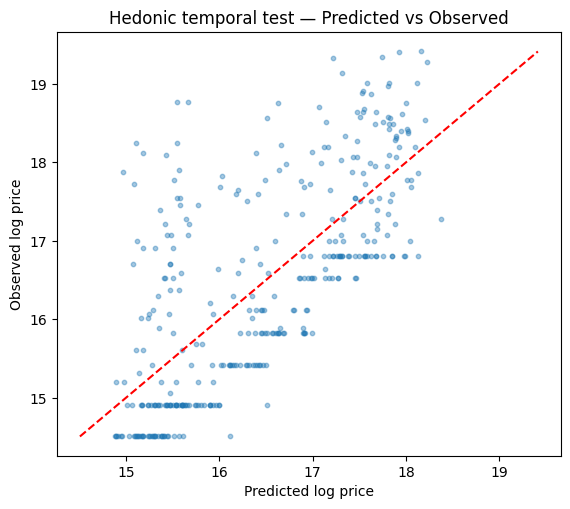

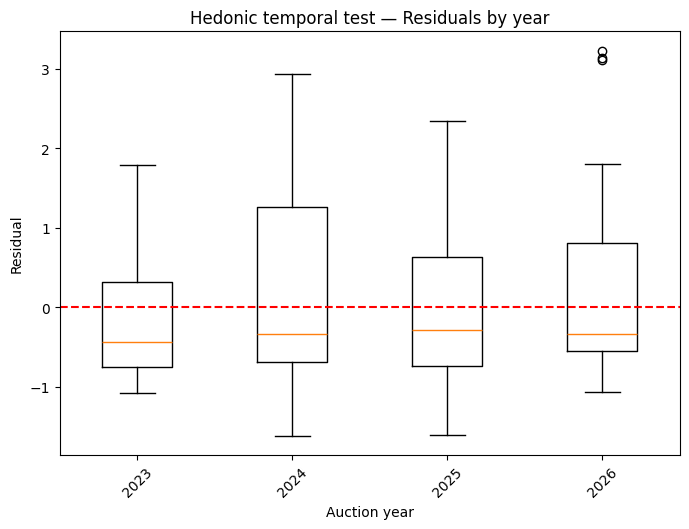

saved hedonic_temporal_test__pred_vs_obs.png  and  hedonic_temporal_test__resid_by_year.png


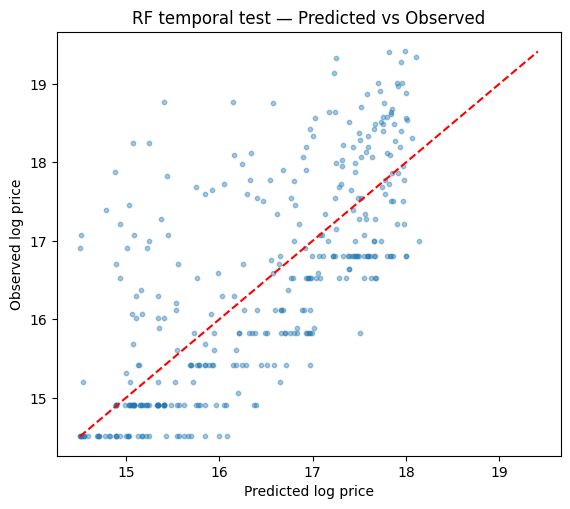

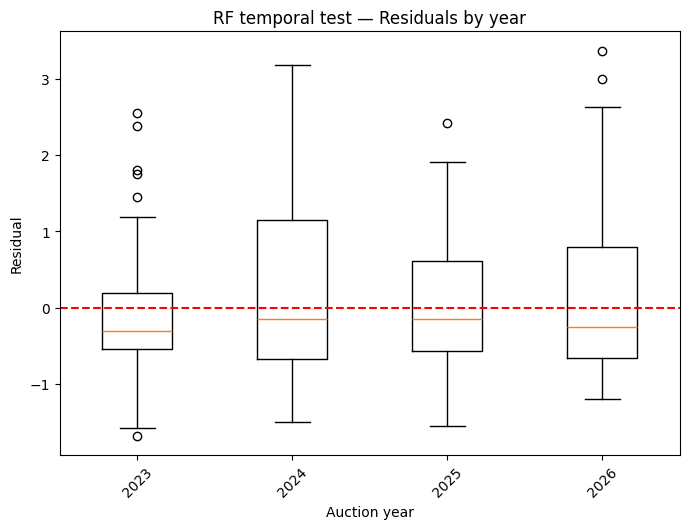

saved rf_temporal_test__pred_vs_obs.png  and  rf_temporal_test__resid_by_year.png


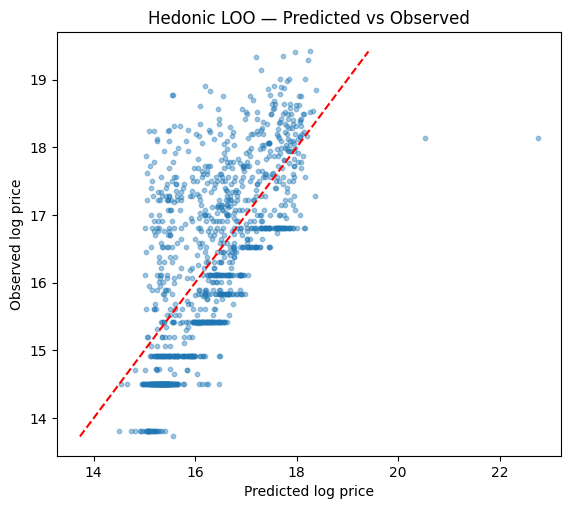

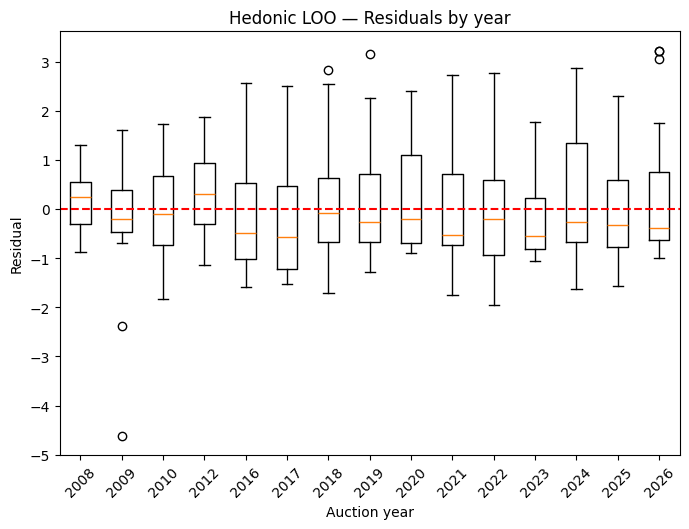

saved hedonic_loo__pred_vs_obs.png  and  hedonic_loo__resid_by_year.png


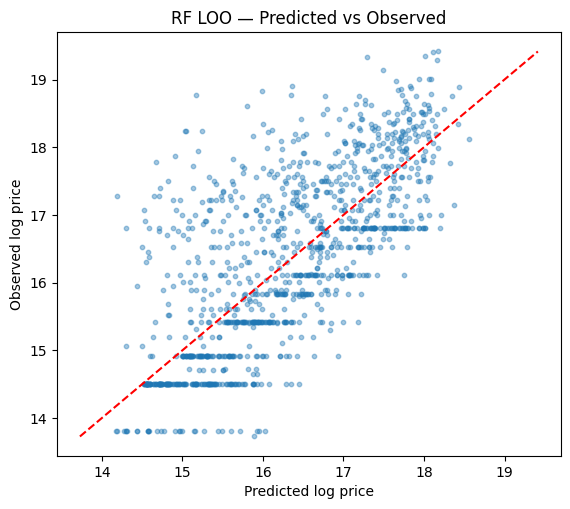

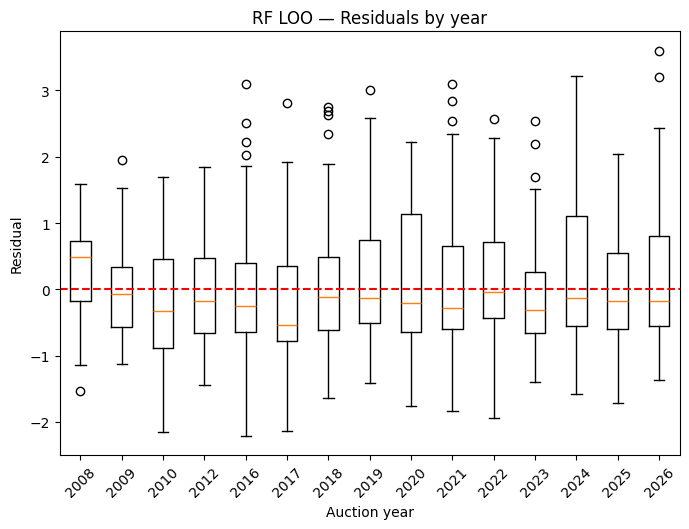

saved rf_loo__pred_vs_obs.png  and  rf_loo__resid_by_year.png


In [196]:

save_plots(new_data["log_price"],  m3_coef.predict(new_data),  new_data["year"],  "Hedonic full data")
save_plots(test_data["log_price"], m3.predict(test_data),      test_data["year"], "Hedonic random test")
save_plots(test_t["log_price"],    m_temporal.predict(test_t), test_t["year"],    "Hedonic temporal test")
save_plots(test_t["log_price"],    rf_t.predict(X_test_t),     test_t["year"],    "RF temporal test")
save_plots(lin_obs, lin_pred, lin_year, "Hedonic LOO")
save_plots(rf_obs,  rf_pred,  rf_year,  "RF LOO")

## Z-Score

In [197]:

df["mapped_player_role"] = df["player_role"].map(role_map)
df["new_base_price_in_cr"] = df["base_price"] / 1e7
df["is_capped"]   = df["is_capped"].fillna(False).astype(int)

df["new_overseas"] = pd.to_numeric(df["new_overseas"].map({True:1, False:0, "True":1, "False":0}), errors="coerce")

df["intl_experience"] = (df["year"] - df["debut_year"]).clip(lower=0).fillna(0)

df["log_price"] = np.log(df["sold_price"].where(df["sold_price"] > 0))


auctioned = df[df["auction_result"].isin(["sold", "unsold"])].copy()



auctioned["has_prior_ipl"] = (
    auctioned["matches"].notna() | auctioned["runs"].notna() | auctioned["wickets"].notna()
).astype(int)
auctioned["has_batting_record"] = auctioned["runs"].notna().astype(int)      # did he bat
auctioned["has_bowling_record"] = auctioned["wickets"].notna().astype(int)   # did he bowl


In [198]:

def z_within_role_year(frame, col, min_n=10):
    g = frame.groupby(["mapped_player_role", "year"])[col]
    z = (frame[col] - g.transform("mean")) / g.transform("std")
    too_small = (g.transform("count") < min_n) | (g.transform("std").fillna(0) == 0)
    gr = frame.groupby("mapped_player_role")[col]
    z_role = (frame[col] - gr.transform("mean")) / gr.transform("std")
    return z.where(~too_small, z_role)


for raw, zc in [("runs", "runs_z"), ("wickets", "wickets_z"),("matches", "matches_z"), ("batting_strikerate", "strike_rate_z")]:
    auctioned[zc] = z_within_role_year(auctioned, raw).fillna(0)

In [199]:

new_data2 = auctioned[(auctioned["auction_result"] == "sold") & auctioned["sold_price"].notna() & (auctioned["sold_price"] > 0)].copy()


new_data2 = new_data2.dropna(subset=["new_base_price_in_cr", "age_during_auction", "mapped_player_role", "is_capped", "new_overseas"]).reset_index(drop=True)


print("sold modelling frame:", len(new_data))

sold modelling frame: 1104


In [200]:
# ---- MODEL A
model_A = ("log_price ~ C(year) + new_base_price_in_cr + age_during_auction + is_capped + new_overseas + C(mapped_player_role) + has_prior_ipl + has_batting_record + has_bowling_record + runs_z + wickets_z + matches_z + strike_rate_z")


model_A_trend = model_A.replace("C(year)", "year")

# ---- MODEL B
model_B = ("log_price ~ C(year) + new_base_price_in_cr + age_during_auction + is_capped + new_overseas + C(mapped_player_role) + has_prior_ipl + has_batting_record + has_bowling_record + runs_z*C(mapped_player_role) + wickets_z*C(mapped_player_role) + matches_z + strike_rate_z")


model_B_trend = model_B.replace("C(year)", "year")

In [201]:

role_d = pd.get_dummies(new_data2["mapped_player_role"], prefix="role", dtype=float)
cols = ["year","new_base_price_in_cr","age_during_auction","is_capped","new_overseas","has_prior_ipl","has_batting_record","has_bowling_record","runs_z","wickets_z","matches_z","strike_rate_z"]

X_rf_z = pd.concat([new_data2[cols], role_d], axis=1)
y_z = new_data2["log_price"].values



In [202]:

tr, te = train_test_split(np.arange(len(new_data2)), test_size=0.2, random_state=42)
train_data = new_data2.iloc[tr]
test_data = new_data2.iloc[te]


train_t = new_data2[new_data2["year"] <= 2022]
test_t  = new_data2[new_data2["year"] >= 2023]
print("random: train", len(tr), "test", len(te), "| temporal: train", len(train_t), "test", len(test_t))

random: train 883 test 221 | temporal: train 750 test 354


## Without Interaction

###Random Split

In [203]:

null_pred = np.full(len(test_data), train_data["log_price"].mean())
print("Null — random:")
test_scores(test_data["log_price"], null_pred)

Null — random:
 TEST: R2 = -0.003 | RMSE = 1.33 | MAE = 1.145


In [204]:

m_season = smf.ols("log_price ~ C(year)", data=train_data).fit()
print("Season — random:")
test_scores(test_data["log_price"], m_season.predict(test_data))

Season — random:
 TEST: R2 = 0.089 | RMSE = 1.268 | MAE = 1.092


In [205]:

m_base = smf.ols("log_price ~ C(year) + new_base_price_in_cr", data=train_data).fit()
print("Base + season — random:")
test_scores(test_data["log_price"], m_base.predict(test_data))

Base + season — random:
 TEST: R2 = 0.431 | RMSE = 1.002 | MAE = 0.831


In [206]:
m2 = smf.ols(model_A, data=train_data).fit()
p2 = m2.predict(test_data)
test_scores(test_data["log_price"], p2)

 TEST: R2 = 0.507 | RMSE = 0.933 | MAE = 0.764


In [207]:

rf_z = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_rf_z.iloc[tr], y_z[tr])
print("RF z-score — random:"); test_scores(y_z[te], rf_z.predict(X_rf_z.iloc[te]))

RF z-score — random:
 TEST: R2 = 0.516 | RMSE = 0.924 | MAE = 0.729


In [208]:

print("Null — temporal:")
test_scores(test_t["log_price"], np.full(len(test_t), train_t["log_price"].mean()))

Null — temporal:
 TEST: R2 = -0.016 | RMSE = 1.374 | MAE = 1.18


In [209]:

m_season_t = smf.ols("log_price ~ year", data=train_t).fit()
print("Season — temporal:")
test_scores(test_t["log_price"], m_season_t.predict(test_t))

Season — temporal:
 TEST: R2 = -0.024 | RMSE = 1.38 | MAE = 1.183


In [210]:

m_base_t = smf.ols("log_price ~ year + new_base_price_in_cr", data=train_t).fit()
print("Base + season — temporal:")
test_scores(test_t["log_price"], m_base_t.predict(test_t))

Base + season — temporal:
 TEST: R2 = 0.491 | RMSE = 0.972 | MAE = 0.834


In [211]:
m_temporal2 = smf.ols(model_A_trend, data=train_t).fit()
p_temporal2 = m_temporal2.predict(test_t)
test_scores(test_t["log_price"], p_temporal2)

 TEST: R2 = 0.508 | RMSE = 0.956 | MAE = 0.744


In [212]:

X_ztr, X_zte = X_rf_z.loc[train_t.index], X_rf_z.loc[test_t.index]
rf_z_t = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_ztr, train_t["log_price"])
print("RF z-score — temporal:"); test_scores(test_t["log_price"], rf_z_t.predict(X_zte))

RF z-score — temporal:
 TEST: R2 = 0.464 | RMSE = 0.998 | MAE = 0.79


In [213]:
rows = []
lin_obs = []; lin_pred = []; lin_year = []
rf_obs = []; rf_pred = []; rf_year = []

for test_year in sorted(new_data2["year"].unique()):
    train_y = new_data2[new_data2["year"] != test_year]
    test_y  = new_data2[new_data2["year"] == test_year]
    if len(test_y) < 5:
        continue

    # null (mean-only)
    p_null = np.full(len(test_y), train_y["log_price"].mean())

    # season only (numeric year, since the held-out year is unseen)
    m_season = smf.ols("log_price ~ year", data=train_y).fit()
    p_season = m_season.predict(test_y)

    # base price + season
    m_base = smf.ols("log_price ~ year + new_base_price_in_cr", data=train_y).fit()
    p_base = m_base.predict(test_y)

    # z-score model (Model A, no interaction)
    m = smf.ols(model_A_trend, data=train_y).fit()
    p_lin = m.predict(test_y)

    # random forest model
    rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(
        X_rf_z.loc[train_y.index], train_y["log_price"])
    p_rf = rf.predict(X_rf_z.loc[test_y.index])

    rows.append({
        "held_out_year": test_year, "n_test": len(test_y),
        "null_R2":   round(r2_score(test_y["log_price"], p_null), 3),
        "season_R2": round(r2_score(test_y["log_price"], p_season), 3),
        "base_R2":   round(r2_score(test_y["log_price"], p_base), 3),
        "lin_R2":    round(r2_score(test_y["log_price"], p_lin), 3),
        "rf_R2":     round(r2_score(test_y["log_price"], p_rf), 3),
    })

    lin_obs += list(test_y["log_price"]); lin_pred += list(p_lin); lin_year += list(test_y["year"])
    rf_obs  += list(test_y["log_price"]); rf_pred  += list(p_rf);  rf_year  += list(test_y["year"])

loo = pd.DataFrame(rows)
print(loo.to_string(index=False))

print("\nNull        — avg R2 =", round(loo["null_R2"].mean(), 3))
print("Season      — avg R2 =", round(loo["season_R2"].mean(), 3))
print("Base+season — avg R2 =", round(loo["base_R2"].mean(), 3))
print("Z-score     — avg R2 =", round(loo["lin_R2"].mean(), 3))
print("Forest      — avg R2 =", round(loo["rf_R2"].mean(), 3))

 held_out_year  n_test  null_R2  season_R2  base_R2  lin_R2  rf_R2
          2008      72   -0.234     -1.584   -0.388  -0.915  0.093
          2009      16   -0.013     -0.071   -2.262  -0.331  0.258
          2010      11   -0.116     -0.063    0.320   0.085  0.269
          2012      23   -0.004     -0.027    0.149   0.544  0.442
          2016      79   -0.190     -0.177    0.321   0.488  0.426
          2017      57   -0.302     -0.284    0.291   0.355  0.444
          2018     151   -0.060     -0.075    0.351   0.458  0.478
          2019      54   -0.054     -0.050    0.300   0.423  0.422
          2020      55   -0.004     -0.004    0.392   0.393  0.332
          2021      50   -0.026     -0.029    0.353   0.467  0.517
          2022     182   -0.008     -0.005    0.428   0.580  0.571
          2023      67   -0.149     -0.183    0.465   0.546  0.523
          2024      61   -0.009     -0.004    0.327   0.289  0.331
          2025     168   -0.083     -0.083    0.575   0.644  0

## With Interaction

In [214]:
m2b = smf.ols(model_B, data=train_data).fit()
p2b = m2b.predict(test_data)
test_scores(test_data["log_price"], p2b)

 TEST: R2 = 0.501 | RMSE = 0.938 | MAE = 0.766


In [215]:
m_temporal2b = smf.ols(model_B_trend, data=train_t).fit()
p_temporal2b = m_temporal2b.predict(test_t)
test_scores(test_t["log_price"], p_temporal2b)

 TEST: R2 = 0.501 | RMSE = 0.963 | MAE = 0.749


In [216]:
m_A = smf.ols(model_A, data=new_data2).fit(cov_type="HC3")
print(m_A.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     49.98
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          8.83e-173
Time:                        19:37:44   Log-Likelihood:                -1450.1
No. Observations:                1104   AIC:                             2958.
Df Residuals:                    1075   BIC:                             3103.
Df Model:                          28                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [217]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp = het_breuschpagan(m_A.resid, m_A.model.exog)
print("Breusch-Pagan (z-score model) p-value:", bp[1])

Breusch-Pagan (z-score model) p-value: 3.58963542559247e-12


In [218]:

new_data3 = new_data2.copy()
new_data3["predicted_log"] = m_A.fittedvalues
new_data3["residual"] = m_A.resid

cols = ["player_name", "year", "mapped_player_role", "sold_price", "residual"]

print("=== MOST OVER-VALUED (paid ABOVE comparable players) ===")
print(new_data3.sort_values("residual", ascending=False)[cols].head(10).to_string(index=False))

print("\n=== MOST UNDER-VALUED (paid BELOW comparable players) ===")
print(new_data3.sort_values("residual")[cols].head(10).to_string(index=False))

=== MOST OVER-VALUED (paid ABOVE comparable players) ===
       player_name  year mapped_player_role  sold_price  residual
Varun Chakravarthy  2019             Bowler  84000000.0  3.118211
           PR Veer  2026         Allrounder 142000000.0  3.035470
        Auqib Nabi  2026             Bowler  84000000.0  2.997932
     Kartik Sharma  2026       Wicketkeeper 142000000.0  2.978150
          M Ashwin  2016             Bowler  45000000.0  2.822704
       Tymal Mills  2017             Bowler 120000000.0  2.796566
     Shubham Dubey  2024            Batsman  58000000.0  2.684487
Gowtham Krishnappa  2018         Allrounder  62000000.0  2.680294
     Shahrukh Khan  2021            Batsman  52500000.0  2.671819
      Jofra Archer  2018             Bowler  72000000.0  2.585963

=== MOST UNDER-VALUED (paid BELOW comparable players) ===
       player_name  year mapped_player_role  sold_price  residual
   Kevin Pietersen  2009            Batsman  75531500.0 -2.290012
     Yusuf Abdulla  2010  

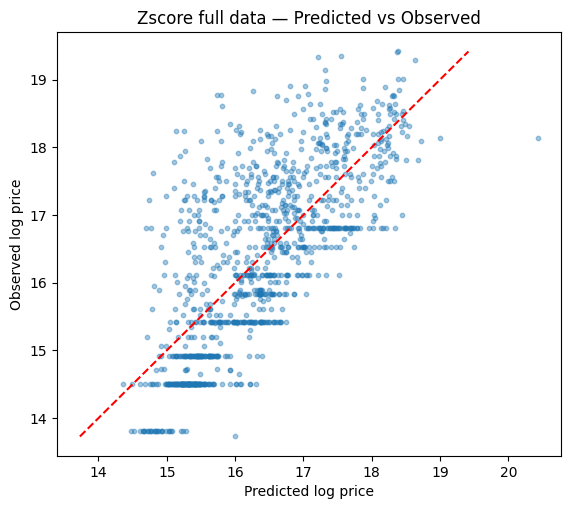

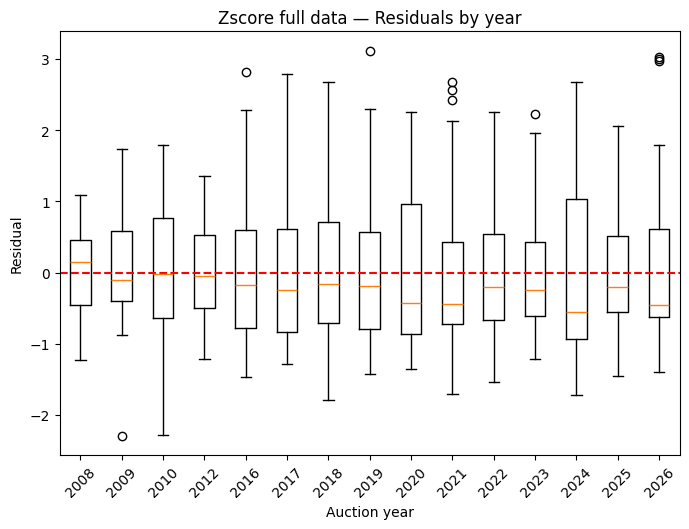

saved zscore_full_data__pred_vs_obs.png  and  zscore_full_data__resid_by_year.png


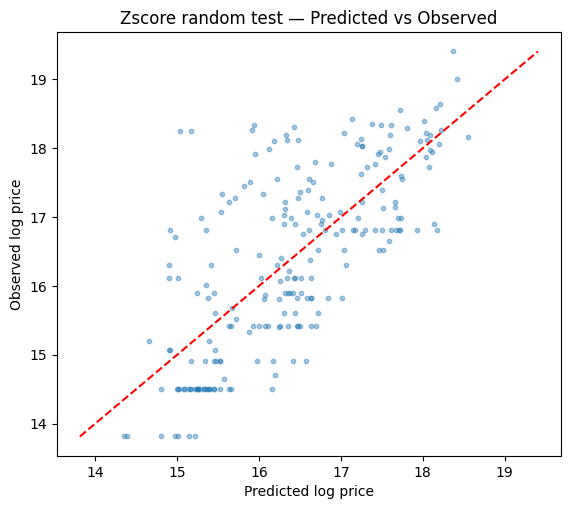

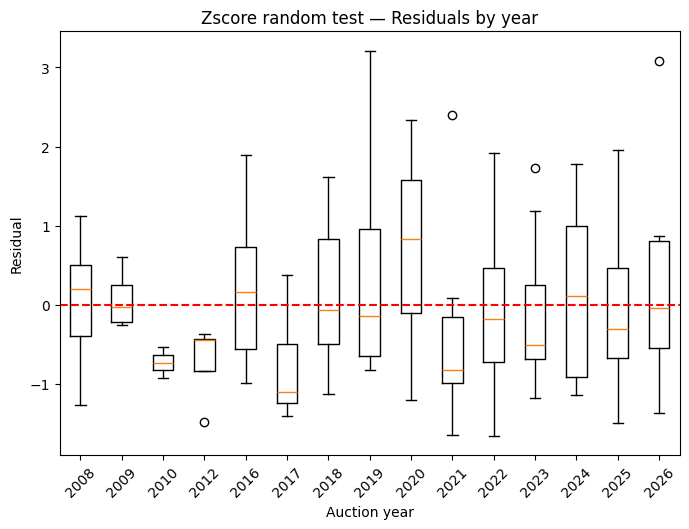

saved zscore_random_test__pred_vs_obs.png  and  zscore_random_test__resid_by_year.png


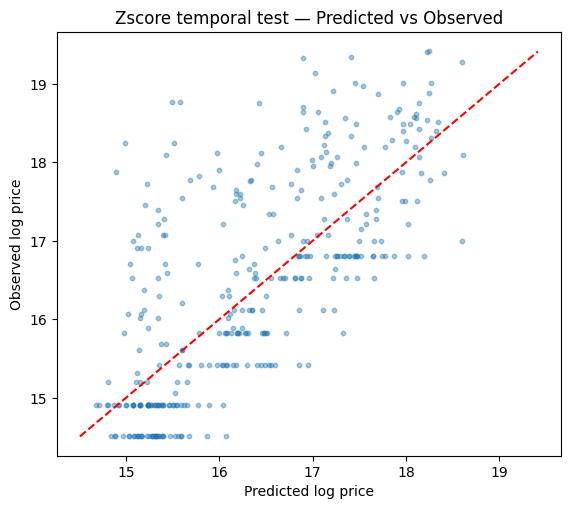

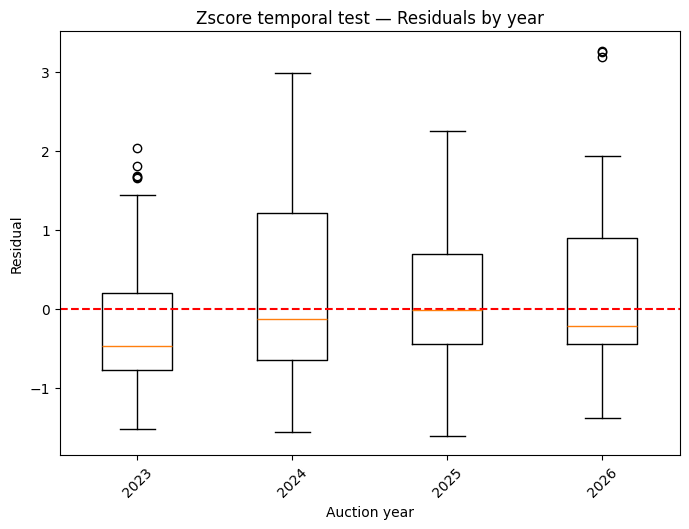

saved zscore_temporal_test__pred_vs_obs.png  and  zscore_temporal_test__resid_by_year.png


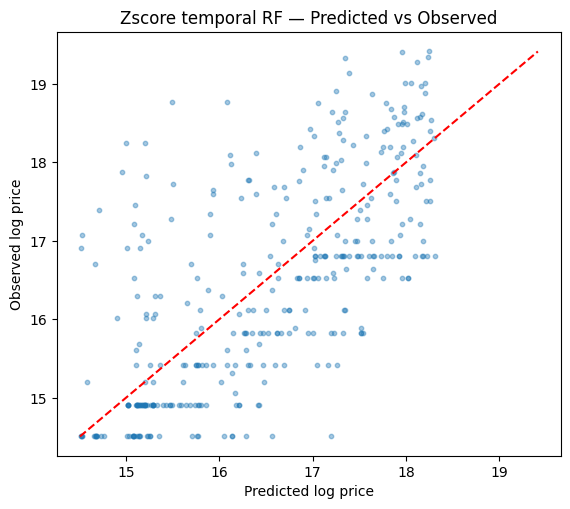

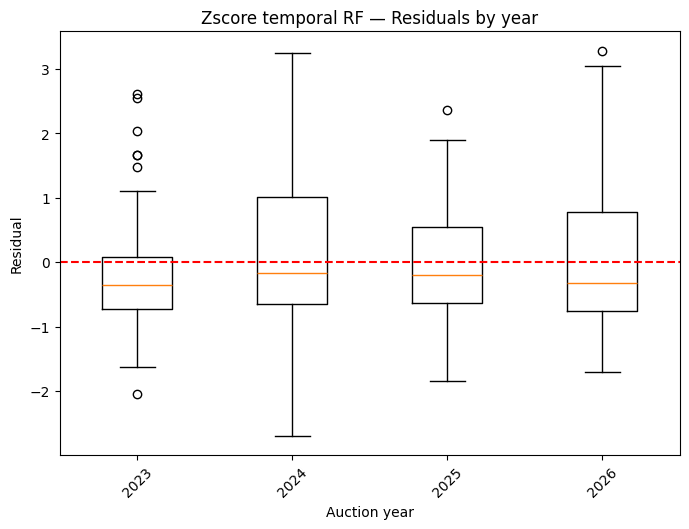

saved zscore_temporal_rf__pred_vs_obs.png  and  zscore_temporal_rf__resid_by_year.png


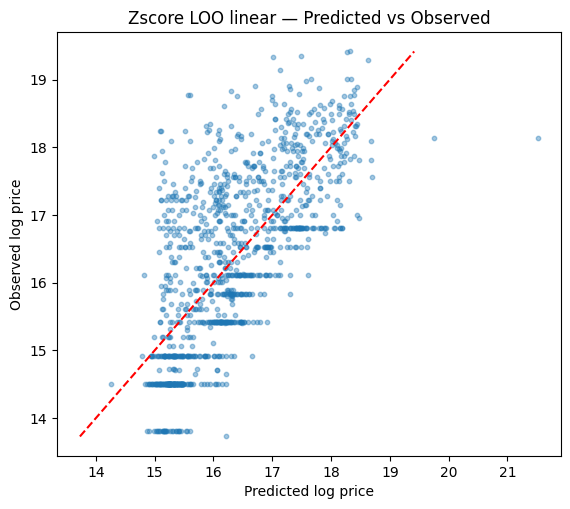

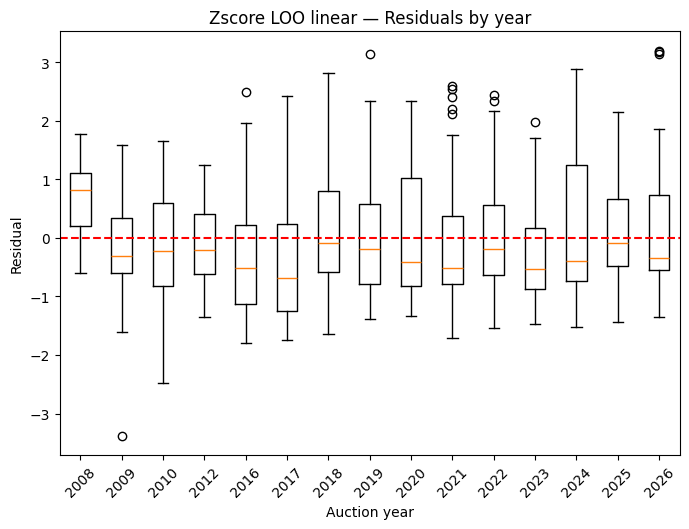

saved zscore_loo_linear__pred_vs_obs.png  and  zscore_loo_linear__resid_by_year.png


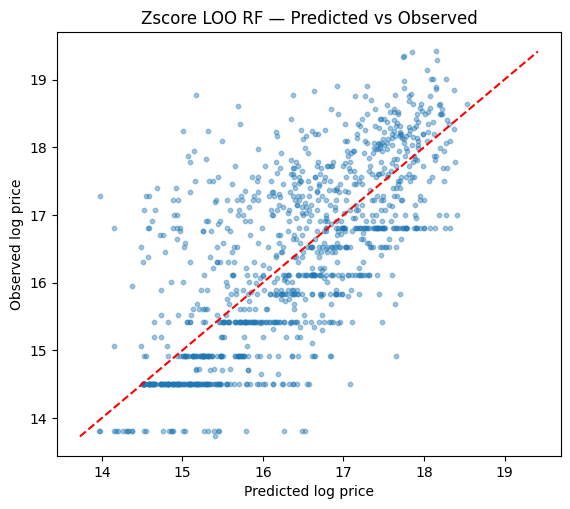

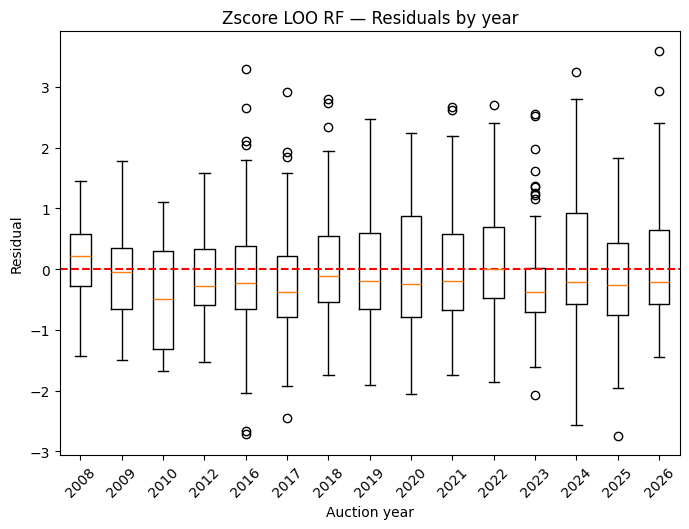

saved zscore_loo_rf__pred_vs_obs.png  and  zscore_loo_rf__resid_by_year.png


In [219]:

save_plots(new_data2["log_price"], m_A.predict(new_data2),   new_data2["year"], "Zscore full data")
save_plots(test_data["log_price"], m2.predict(test_data),    test_data["year"], "Zscore random test")
save_plots(test_t["log_price"],    m_temporal2.predict(test_t), test_t["year"], "Zscore temporal test")
save_plots(test_t["log_price"],    rf_z_t.predict(X_zte),     test_t["year"],    "Zscore temporal RF")
save_plots(lin_obs, lin_pred, lin_year, "Zscore LOO linear")
save_plots(rf_obs,  rf_pred,  rf_year,  "Zscore LOO RF")